In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/1
    print("準備完了！このまま下のセルを実行できます。")

# 1.2 確率論 (Probability Theory)

パターン認識と機械学習のすべてのアルゴリズムの基礎となるのは**確率論 (Probability Theory)** です。
観測データのノイズや、有限なサンプルサイズに起因する不確実性（Uncertainty）を定量的に扱い、最適な予測と推論を行うための数学的言語を提供します。

本ノートブックでは、PRML第1章1.2節の全理論体系をスクラッチから完全実装・可視化します：
- **1.2.1 確率の加法定理・乗法定理 (Sum Rule & Product Rule)** とフルーツボックス問題のベイズ更新
- **1.2.2 期待値・分散・共分散 (Expectations and Covariances)**
- **1.2.3 ベイズの定理 (Bayes' Theorem)**：事前確率から事後確率への更新プロセス
- **1.2.4 ガウス分布 (The Gaussian Distribution)**：多変量正規分布と最尤推定量のバイアス（PRML Figure 1.15）
- **1.2.5 曲線フィッティングの確率論的再考 (Curve Fitting Re-visited)**：最尤推定と二乗和誤差の等価性、予測分布、MAP推定
- **1.2.6 ベイズ曲線フィッティング (Bayesian Curve Fitting)**：完全ベイズ推論による予測分布と不確実性の可視化（PRML Figure 1.16, Figure 1.17）

## 1.2.1 確率の基本規則 & 1.2.3 ベイズの定理

離散確率変数 $X \in \{x_i\}$ と $Y \in \{y_j\}$ に対する確率論の2大基本規則：

1. **加法定理 (Sum Rule)**（PRML 式 1.7）：
$$
p(X = x_i) = \sum_{j=1}^L p(X = x_i, Y = y_j)
$$
2. **乗法定理 (Product Rule)**（PRML 式 1.8）：
$$
p(X = x_i, Y = y_j) = p(Y = y_j | X = x_i) p(X = x_i)
$$

この2つの規則から直ちに**ベイズの定理 (Bayes' Theorem)**（PRML 式 1.12）が導かれます：
$$
p(Y = y_j | X = x_i) = \frac{p(X = x_i | Y = y_j) p(Y = y_j)}{p(X = x_i)} = \frac{p(X = x_i | Y = y_j) p(Y = y_j)}{\sum_k p(X = x_i | Y = y_k) p(Y = y_k)}
$$

### フルーツボックス問題のシミュレーション
PRMLの導入例：赤い箱（$r$）と青い箱（$b$）があり、それぞれリンゴ（$a$）とオレンジ（$o$）が入っています。
- 箱の選択確率（事前確率）: $p(B=r) = 0.4, \quad p(B=b) = 0.6$
- 赤い箱の内容: リンゴ 2個、オレンジ 6個 $\implies p(F=a|B=r) = 1/4, \; p(F=o|B=r) = 3/4$
- 青い箱の内容: リンゴ 3個、オレンジ 1個 $\implies p(F=a|B=b) = 3/4, \; p(F=o|B=b) = 1/4$

選ばれた果物が「オレンジ」だったとき、それが赤い箱から選ばれた確率 $p(B=r|F=o)$ をベイズの定理で計算し、モンテカルロシミュレーションで検証します。

理論計算:
  P(F = orange) = 0.4500
  P(B = red  | F = orange) = 0.6667
  P(B = blue | F = orange) = 0.3333
モンテカルロ検証 (N=100000):
  Simulated P(B = red | F = orange) = 0.6643
Plot saved to: result/fig1_fruit_box_bayes.png


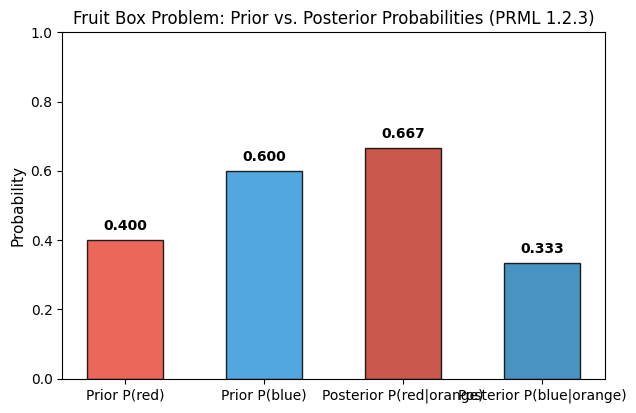

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
setup_style()

# 事前確率
p_B = {'red': 0.4, 'blue': 0.6}

# 条件付き確率 p(F | B)
p_F_given_B = {
    'red':  {'apple': 2/8, 'orange': 6/8},
    'blue': {'apple': 3/4, 'orange': 1/4}
}

# 1. 加法定理: 果物の周辺確率 p(F)
p_orange = p_F_given_B['red']['orange'] * p_B['red'] + p_F_given_B['blue']['orange'] * p_B['blue']
p_apple  = p_F_given_B['red']['apple'] * p_B['red'] + p_F_given_B['blue']['apple'] * p_B['blue']

# 2. ベイズの定理: オレンジが選ばれたときの箱の事後確率 p(B | F=orange)
p_red_given_orange = (p_F_given_B['red']['orange'] * p_B['red']) / p_orange
p_blue_given_orange = (p_F_given_B['blue']['orange'] * p_B['blue']) / p_orange

print(f"理論計算:")
print(f"  P(F = orange) = {p_orange:.4f}")
print(f"  P(B = red  | F = orange) = {p_red_given_orange:.4f}")
print(f"  P(B = blue | F = orange) = {p_blue_given_orange:.4f}")

# モンテカルロシミュレーションによる実験的検証
N_trials = 100000
boxes = np.random.choice(['red', 'blue'], size=N_trials, p=[0.4, 0.6])
fruits = []
for b in boxes:
    prob_orange = p_F_given_B[b]['orange']
    fruits.append('orange' if np.random.rand() < prob_orange else 'apple')
fruits = np.array(fruits)

# オレンジが選ばれた試行における赤い箱の割合
orange_indices = np.where(fruits == 'orange')[0]
sim_p_red_given_orange = np.mean(boxes[orange_indices] == 'red')
print(f"モンテカルロ検証 (N={N_trials}):")
print(f"  Simulated P(B = red | F = orange) = {sim_p_red_given_orange:.4f}")

# 可視化
fig, ax = plt.subplots(figsize=(7, 4.5))
categories = ['Prior P(red)', 'Prior P(blue)', 'Posterior P(red|orange)', 'Posterior P(blue|orange)']
probs = [p_B['red'], p_B['blue'], p_red_given_orange, p_blue_given_orange]
colors = ['#e74c3c', '#3498db', '#c0392b', '#2980b9']

bars = ax.bar(categories, probs, color=colors, width=0.55, edgecolor='black', alpha=0.85)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Probability', fontsize=11)
ax.set_title("Fruit Box Problem: Prior vs. Posterior Probabilities (PRML 1.2.3)", fontsize=12)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

save_plot(fig, 'result', 'fig1_fruit_box_bayes.png')
plt.show()

## 1.2.4 ガウス分布 (The Gaussian Distribution)

実数値変数 $x$ のガウス分布（正規分布）は以下のように定義されます（PRML 式 1.46）：
$$
\mathcal{N}(x | \mu, \sigma^2) = \frac{1}{(2\pi\sigma^2)^{1/2}} \exp\left\{ -\frac{1}{2\sigma^2}(x - \mu)^2 \right\}
$$
ここで $\mu$ は平均、$\sigma^2$ は分散、$\beta = 1/\sigma^2$ は精度（precision）です。

### 最尤推定量のバイアス (Bias of Maximum Likelihood)
独立同分布な $N$ 個の観測データ $\mathbf{x} = (x_1, \ldots, x_N)^T$ に対する対数尤度関数は：
$$
\ln p(\mathbf{x} | \mu, \sigma^2) = -\frac{1}{2\sigma^2}\sum_{n=1}^N (x_n - \mu)^2 - \frac{N}{2}\ln \sigma^2 - \frac{N}{2}\ln(2\pi)
$$
対数尤度を $\mu$ および $\sigma^2$ で偏微分してゼロとおくことで、最尤推定量が得られます（PRML 式 1.55, 1.56）：
$$
\mu_{\mathrm{ML}} = \frac{1}{N}\sum_{n=1}^N x_n, \qquad \sigma_{\mathrm{ML}}^2 = \frac{1}{N}\sum_{n=1}^N (x_n - \mu_{\mathrm{ML}})^2
$$

これらの推定量について、真の分布に対する期待値を求めると：
$$
\mathbb{E}[\mu_{\mathrm{ML}}] = \mu \quad (\text{不偏推定量})
$$
$$
\mathbb{E}[\sigma_{\mathrm{ML}}^2] = \left(\frac{N-1}{N}\right) \sigma^2 \quad (\text{負のバイアス：真の分散を過小評価})
$$
最尤推定における分散の過小評価は、**過学習 (Overfitting)** 現象の最も根源的な現れです。不偏分散は分母を $N-1$ とすることで得られます：
$$
\tilde{\sigma}^2 = \frac{N}{N-1}\sigma_{\mathrm{ML}}^2 = \frac{1}{N-1}\sum_{n=1}^N (x_n - \mu_{\mathrm{ML}})^2
$$

### PRML Figure 1.15 の再現
データ点数が $N=2$ の極小サンプルにおいて、最尤分散が真の分散よりも系統的に小さくなる幾何学的直観を可視化します。

真の分散: 1.000
最尤分散の平均 (実験値): 0.507 (理論値: 0.500)
不偏分散の平均 (実験値): 1.013


Plot saved to: result/fig1_15_ml_bias.png


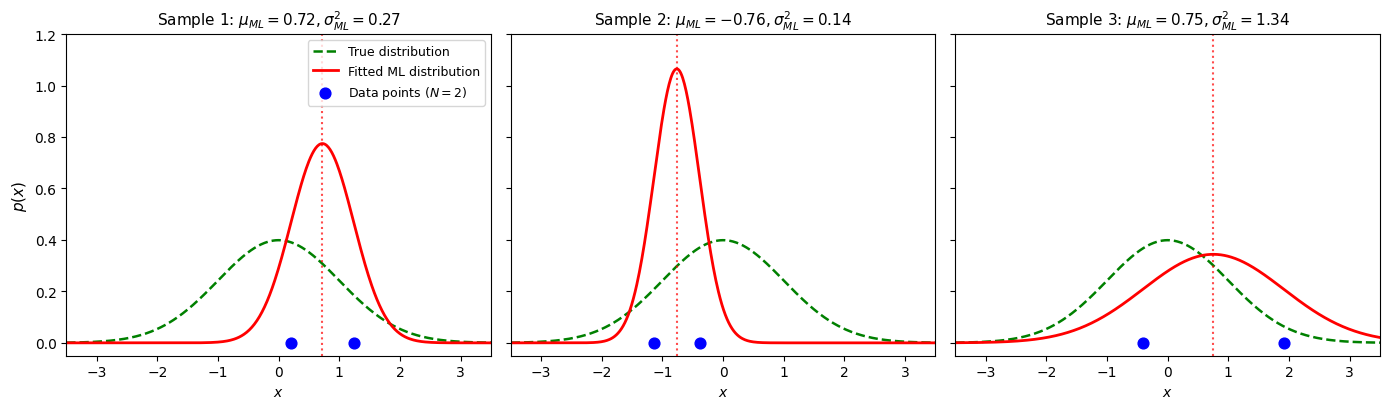

In [2]:
# PRML Figure 1.15 の再現: 最尤分散のバイアス
mu_true, var_true = 0.0, 1.0
std_true = np.sqrt(var_true)

N_samples = 2  # サンプルサイズ N=2
N_datasets = 10000

# 多数のデータセットをシミュレーション
datasets = np.random.normal(mu_true, std_true, size=(N_datasets, N_samples))
mu_mls = np.mean(datasets, axis=1)
var_mls = np.var(datasets, axis=1, ddof=0)  # ML推定量 (分母 N)
var_unbiased = np.var(datasets, axis=1, ddof=1)  # 不偏推定量 (分母 N-1)

mean_var_ml = np.mean(var_mls)
theoretical_bias = (N_samples - 1) / N_samples * var_true

print(f"真の分散: {var_true:.3f}")
print(f"最尤分散の平均 (実験値): {mean_var_ml:.3f} (理論値: {theoretical_bias:.3f})")
print(f"不偏分散の平均 (実験値): {np.mean(var_unbiased):.3f}")

# プロット作成
x_grid = np.linspace(-3.5, 3.5, 500)
p_true = (1 / np.sqrt(2 * np.pi * var_true)) * np.exp(-0.5 * (x_grid - mu_true)**2 / var_true)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)

# 3つの異なるサンプルセットでの最尤ガウス分布を表示 (PRML Figure 1.15 のレイアウト)
for i, ax in enumerate(axes):
    pts = datasets[i]
    mu_est = np.mean(pts)
    var_est = np.var(pts)
    if var_est < 1e-4: var_est = 1e-4
    
    p_est = (1 / np.sqrt(2 * np.pi * var_est)) * np.exp(-0.5 * (x_grid - mu_est)**2 / var_est)
    
    ax.plot(x_grid, p_true, 'g--', lw=1.8, label='True distribution')
    ax.plot(x_grid, p_est, 'r-', lw=2.0, label='Fitted ML distribution')
    ax.scatter(pts, [0, 0], color='blue', s=60, zorder=5, label='Data points ($N=2$)')
    ax.axvline(mu_est, color='red', linestyle=':', alpha=0.7)
    
    ax.set_title(f'Sample {i+1}: $\\mu_{{ML}}={mu_est:.2f}, \\sigma^2_{{ML}}={var_est:.2f}$', fontsize=11)
    ax.set_xlabel('$x$', fontsize=10)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-0.05, 1.2)
    if i == 0:
        ax.set_ylabel('$p(x)$', fontsize=11)
        ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_15_ml_bias.png')
plt.show()

## 1.2.5 曲線フィッティングの再考 (Curve Fitting Re-visited)

第1.1節で扱った多項式曲線フィッティングを、確率論の観点から再定式化します。
真の関数 $y(x, \mathbf{w}) = \sum_{j=0}^M w_j x^j$ に対し、目標変数 $t$ に平均0、分散 $\sigma^2 = \beta^{-1}$ のガウスノイズが加わると仮定します（PRML 式 1.60）：
$$
p(t | x, \mathbf{w}, \beta) = \mathcal{N}(t | y(x, \mathbf{w}), \beta^{-1})
$$

独立同分布な訓練データ $\mathbf{x} = (x_1, \ldots, x_N)^T$, $\mathbf{t} = (t_1, \ldots, t_N)^T$ に対する尤度関数は：
$$
p(\mathbf{t} | \mathbf{x}, \mathbf{w}, \beta) = \prod_{n=1}^N \mathcal{N}(t_n | y(x_n, \mathbf{w}), \beta^{-1})
$$
その対数尤度は（PRML 式 1.62）：
$$
\ln p(\mathbf{t} | \mathbf{x}, \mathbf{w}, \beta) = -\frac{\beta}{2} \sum_{n=1}^N \{y(x_n, \mathbf{w}) - t_n\}^2 + \frac{N}{2}\ln \beta - \frac{N}{2}\ln(2\pi)
$$

### 最尤推定と二乗和誤差の等価性
$\mathbf{w}$ に関して対数尤度を最大化することは、二乗和誤差関数 $E(\mathbf{w}) = \frac{1}{2}\sum_{n=1}^N \{y(x_n, \mathbf{w}) - t_n\}^2$ を最小化することと**完全に等価**です！
また、精度 $\beta$ の最尤推定量は：
$$
\frac{1}{\beta_{\mathrm{ML}}} = \frac{1}{N}\sum_{n=1}^N \{y(x_n, \mathbf{w}_{\mathrm{ML}}) - t_n\}^2
$$
となり、フィッティング残差の二乗平均となります。

### MAP推定 (Maximum A Posteriori) と正則化の起源
重みベクトル $\mathbf{w}$ に事前分布として平均 $\mathbf{0}$、分散 $\alpha^{-1}\mathbf{I}$ のガウス分布を導入します：
$$
p(\mathbf{w} | \alpha) = \mathcal{N}(\mathbf{w} | \mathbf{0}, \alpha^{-1}\mathbf{I}) = \left(\frac{\alpha}{2\pi}\right)^{(M+1)/2} \exp\left\{ -\frac{\alpha}{2}\mathbf{w}^T\mathbf{w} \right\}
$$
ベイズの定理より事後分布は $p(\mathbf{w}|\mathbf{x}, \mathbf{t}, \alpha, \beta) \propto p(\mathbf{t}|\mathbf{x}, \mathbf{w}, \beta) p(\mathbf{w}|\alpha)$。
事後確率の対数は：
$$
\ln p(\mathbf{w} | \mathbf{x}, \mathbf{t}, \alpha, \beta) = -\frac{\beta}{2}\sum_{n=1}^N \{y(x_n, \mathbf{w}) - t_n\}^2 - \frac{\alpha}{2}\mathbf{w}^T\mathbf{w} + \text{const}
$$
これを最大化することは、以下の正則化誤差関数を最小化することと等価です：
$$
\frac{1}{2}\sum_{n=1}^N \{y(x_n, \mathbf{w}) - t_n\}^2 + \frac{\lambda}{2}\mathbf{w}^T\mathbf{w}, \qquad \lambda = \frac{\alpha}{\beta}
$$
すなわち、**L2正則化（Ridge回帰）は、ガウス事前分布のもとでのMAP推定と厳密に等価**であることが分かります！

## 1.2.6 ベイズ曲線フィッティング (Bayesian Curve Fitting)

MAP推定では依然として点推定（単一の $\mathbf{w}$）を行っていましたが、**真のベイズ的アプローチ**では、パラメータ $\mathbf{w}$ のすべての可能な値について周辺化（積分消去）を行います。

新しい入力値 $x$ に対する予測分布 $p(t|x, \mathbf{x}, \mathbf{t})$ は以下で与えられます（PRML 式 1.68）：
$$
p(t | x, \mathbf{x}, \mathbf{t}) = \int p(t | x, \mathbf{w}) p(\mathbf{w} | \mathbf{x}, \mathbf{t}) d\mathbf{w}
$$
事前分布 $p(\mathbf{w})$ と尤度 $p(t|x, \mathbf{w})$ がともにガウス分布であるため、この積分は解析的に実行でき、予測分布もまたガウス分布となります（PRML 式 1.69）：
$$
p(t | x, \mathbf{x}, \mathbf{t}) = \mathcal{N}(t | m(x), s^2(x))
$$
ここで、予測平均 $m(x)$ と予測分散 $s^2(x)$ は（PRML 式 1.70, 1.71）：
$$
m(x) = \beta \boldsymbol{\phi}(x)^T \mathbf{S} \sum_{n=1}^N \boldsymbol{\phi}(x_n) t_n
$$
$$
s^2(x) = \beta^{-1} + \boldsymbol{\phi}(x)^T \mathbf{S} \boldsymbol{\phi}(x)
$$
行列 $\mathbf{S}$ は事後共分散行列であり、以下で定義されます（PRML 式 1.72）：
$$
\mathbf{S}^{-1} = \alpha \mathbf{I} + \beta \sum_{n=1}^N \boldsymbol{\phi}(x_n) \boldsymbol{\phi}(x_n)^T
$$
ここで $\boldsymbol{\phi}(x) = (1, x, x^2, \ldots, x^M)^T$ は多項式基底ベクトルです。

### 不確実性の分解
予測分散 $s^2(x)$ は2つの項の和から構成されます：
1. $\beta^{-1}$: 目標変数 $t$ 自身が持つ本質的な観測ノイズ（Aleatoric Uncertainty）
2. $\boldsymbol{\phi}(x)^T \mathbf{S} \boldsymbol{\phi}(x)$: パラメータ $\mathbf{w}$ の不確実性に起因する分散（Epistemic Uncertainty）。**データ点が存在しない領域で大きく増大し、データが豊富にある領域で小さくなる**という極めて望ましい性質を持ちます。

### PRML Figure 1.16, Figure 1.17 の再現
最尤推定の予測分布（分散が入力によらず一定）と、ベイズ曲線フィッティングの予測分布（データ点近傍で分散が絞られ、データから離れると不確実性が広がる）を完全再現します。

Plot saved to: result/fig1_17_bayesian_predictive.png


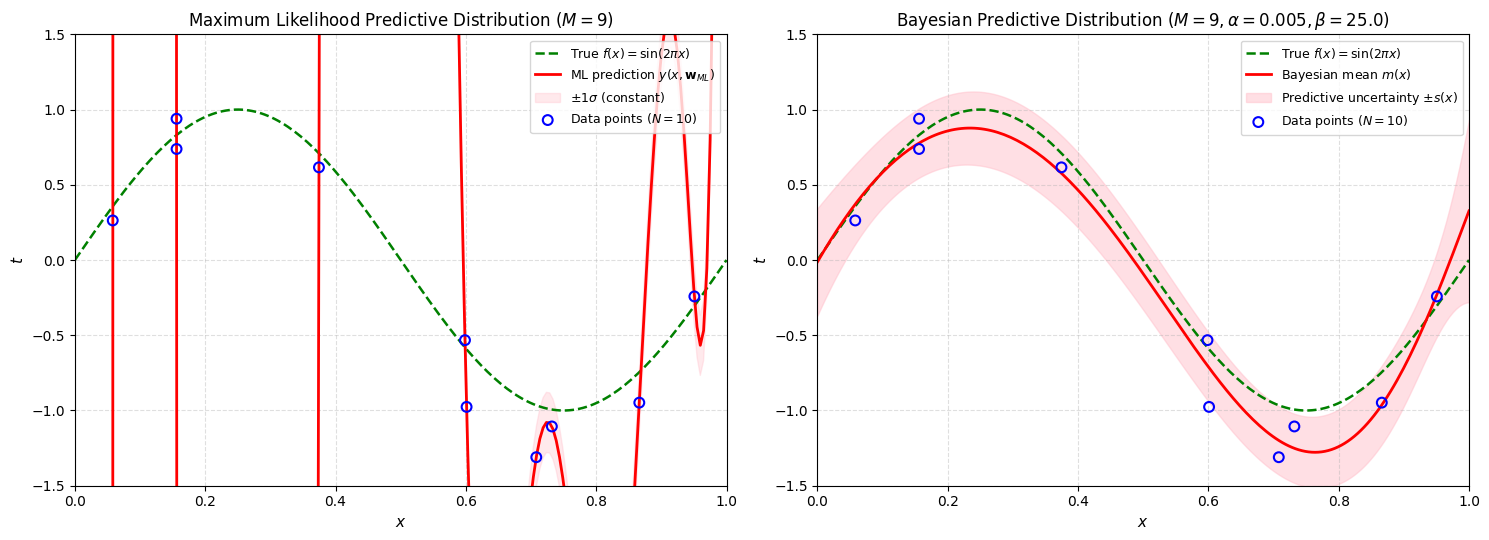

In [3]:
# PRML Figure 1.16 & Figure 1.17 の再現: ベイズ曲線フィッティング
np.random.seed(42)

# 真の関数とデータ生成
def true_fn(x):
    return np.sin(2 * np.pi * x)

N = 10
x_train = np.sort(np.random.uniform(0, 1, N))
beta_true = 1.0 / (0.2**2)  # noise variance 0.2^2
t_train = true_fn(x_train) + np.random.normal(0, 0.2, N)

# 多項式次数 M
M = 9
alpha = 0.005  # 事前分布の精度
beta = beta_true

def design_matrix(x, degree):
    return np.vstack([x**i for i in range(degree + 1)]).T

# 計画行列 Phi
Phi = design_matrix(x_train, M)  # (N, M+1)

# 1. 最尤推定 (ML)
w_ml = np.linalg.pinv(Phi) @ t_train
var_ml = np.mean((t_train - Phi @ w_ml)**2)

# 2. 完全ベイズ推論 (Bayesian)
S_inv = alpha * np.eye(M + 1) + beta * (Phi.T @ Phi)
S = np.linalg.inv(S_inv)

x_test = np.linspace(0, 1, 200)
Phi_test = design_matrix(x_test, M)

# 最尤予測
y_ml = Phi_test @ w_ml

# ベイズ予測平均と予測分散 (式 1.70, 1.71)
m_x = beta * (Phi_test @ S @ Phi.T @ t_train)
s2_x = 1.0 / beta + np.sum(Phi_test @ S * Phi_test, axis=1)
s_x = np.sqrt(s2_x)

# 可視化 (2パネル比較)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# パネル 1: 最尤推定の予測分布 (PRML Figure 1.16)
ax1 = axes[0]
ax1.plot(x_test, true_fn(x_test), 'g--', lw=1.8, label='True $f(x) = \\sin(2\\pi x)$')
ax1.plot(x_test, y_ml, 'r-', lw=2.0, label='ML prediction $y(x, \\mathbf{w}_{ML})$')
ax1.fill_between(x_test, y_ml - 1.0/np.sqrt(beta), y_ml + 1.0/np.sqrt(beta), color='pink', alpha=0.35, label='$\\pm 1\\sigma$ (constant)')
ax1.scatter(x_train, t_train, facecolors='none', edgecolors='b', s=50, lw=1.5, zorder=5, label='Data points ($N=10$)')
ax1.set_xlim(0, 1); ax1.set_ylim(-1.5, 1.5)
ax1.set_title(f'Maximum Likelihood Predictive Distribution ($M={M}$)', fontsize=12)
ax1.set_xlabel('$x$', fontsize=11); ax1.set_ylabel('$t$', fontsize=11)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

# パネル 2: ベイズ予測分布 (PRML Figure 1.17)
ax2 = axes[1]
ax2.plot(x_test, true_fn(x_test), 'g--', lw=1.8, label='True $f(x) = \\sin(2\\pi x)$')
ax2.plot(x_test, m_x, 'r-', lw=2.0, label='Bayesian mean $m(x)$')
ax2.fill_between(x_test, m_x - s_x, m_x + s_x, color='pink', alpha=0.5, label='Predictive uncertainty $\\pm s(x)$')
ax2.scatter(x_train, t_train, facecolors='none', edgecolors='b', s=50, lw=1.5, zorder=5, label='Data points ($N=10$)')
ax2.set_xlim(0, 1); ax2.set_ylim(-1.5, 1.5)
ax2.set_title(f'Bayesian Predictive Distribution ($M={M}, \\alpha={alpha}, \\beta={beta:.1f}$)', fontsize=12)
ax2.set_xlabel('$x$', fontsize=11); ax2.set_ylabel('$t$', fontsize=11)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_17_bayesian_predictive.png')
plt.show()

## まとめ

本節で学んだ確率論の重要概念：
1. **加法定理と乗法定理**: すべての確率推論の礎。
2. **ベイズの定理**: 観測データを得ることで事前信念を事後信念へと更新する道具。
3. **最尤推定量とバイアス**: 最尤推定による分散は $(N-1)/N$ の係数で過小評価される。これが過学習の統計的本質。
4. **最尤推定 $\iff$ 二乗和誤差最小化**: ガウスノイズ仮定のもとで両者は厳密に等価。
5. **MAP推定 $\iff$ 正則化回帰**: ガウス事前分布のもとでの事後最大化が Ridge 正則化（$\lambda = \alpha/\beta$）を自然に導く。
6. **完全ベイズ曲線フィッティング**: 重みパラメータを積分消去することで、データのない領域で不確実性が広がる予測分布 $p(t|x, \mathbf{x}, \mathbf{t}) = \mathcal{N}(t | m(x), s^2(x))$ を導出できる。